In [1]:
# ============================================================
#  The Phoenix Portfolio: Hidden Recovery Plays
#  Returns, Risk, Diversification & Regression Analysis
# ============================================================
#  Author    : Kesidis Angelos
#  Stocks    : MET, DAL, OXY, SLB, KHC
#  Benchmark : S&P 500 (^GSPC)
#  Period    : 2015-01-01 to 2025-05-01
#  Purpose   : Log returns, risk metrics, covariance/correlation,
#              portfolio risk decomposition, regression (OLS),
#              beta/alpha analysis, benchmark comparison
# ============================================================

In [2]:
# ── IMPORTS ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
import statsmodels.api as sm
 
%matplotlib inline

In [3]:
# ============================================================
# SECTION 1 — DATA COLLECTION & CLEANING
# ============================================================

stocks    = ["MET", "DAL", "OXY", "SLB", "KHC"]
benchmark = ["^GSPC"]
assets    = stocks + benchmark
 
start = "2015-01-01"
end   = "2025-05-01"
 
# Download closing prices for all assets
data = yf.download(assets, start=start, end=end)["Close"]
 
# Basic diagnostics
print("Shape   :", data.shape)
print("Columns :", list(data.columns))
print("\n--- First 5 rows ---")
print(data.head())
print("\n--- Last 5 rows ---")
print(data.tail())
print("\n--- Missing values per column ---")
print(data.isnull().sum())

[*********************100%***********************]  6 of 6 completed

Shape   : (2597, 6)
Columns : ['DAL', 'KHC', 'MET', 'OXY', 'SLB', '^GSPC']

--- First 5 rows ---
Ticker            DAL  KHC        MET        OXY        SLB        ^GSPC
Date                                                                    
2015-01-02  42.834660  NaN  32.734337  57.638042  62.534641  2058.199951
2015-01-05  42.120461  NaN  31.641361  55.501183  60.841160  2020.579956
2015-01-06  41.127548  NaN  30.681982  55.029518  59.651356  2002.609985
2015-01-07  40.909805  NaN  31.088812  55.036652  59.644047  2025.900024
2015-01-08  41.972393  NaN  31.562439  55.522625  60.366703  2062.139893

--- Last 5 rows ---
Ticker            DAL        KHC        MET        OXY        SLB        ^GSPC
Date                                                                          
2025-04-24  41.399967  27.861288  73.107765  39.514210  33.893940  5484.770020
2025-04-25  40.966465  27.720291  72.462082  39.504425  33.496105  5525.209961
2025-04-28  41.340855  27.081095  73.184860  39.651241 

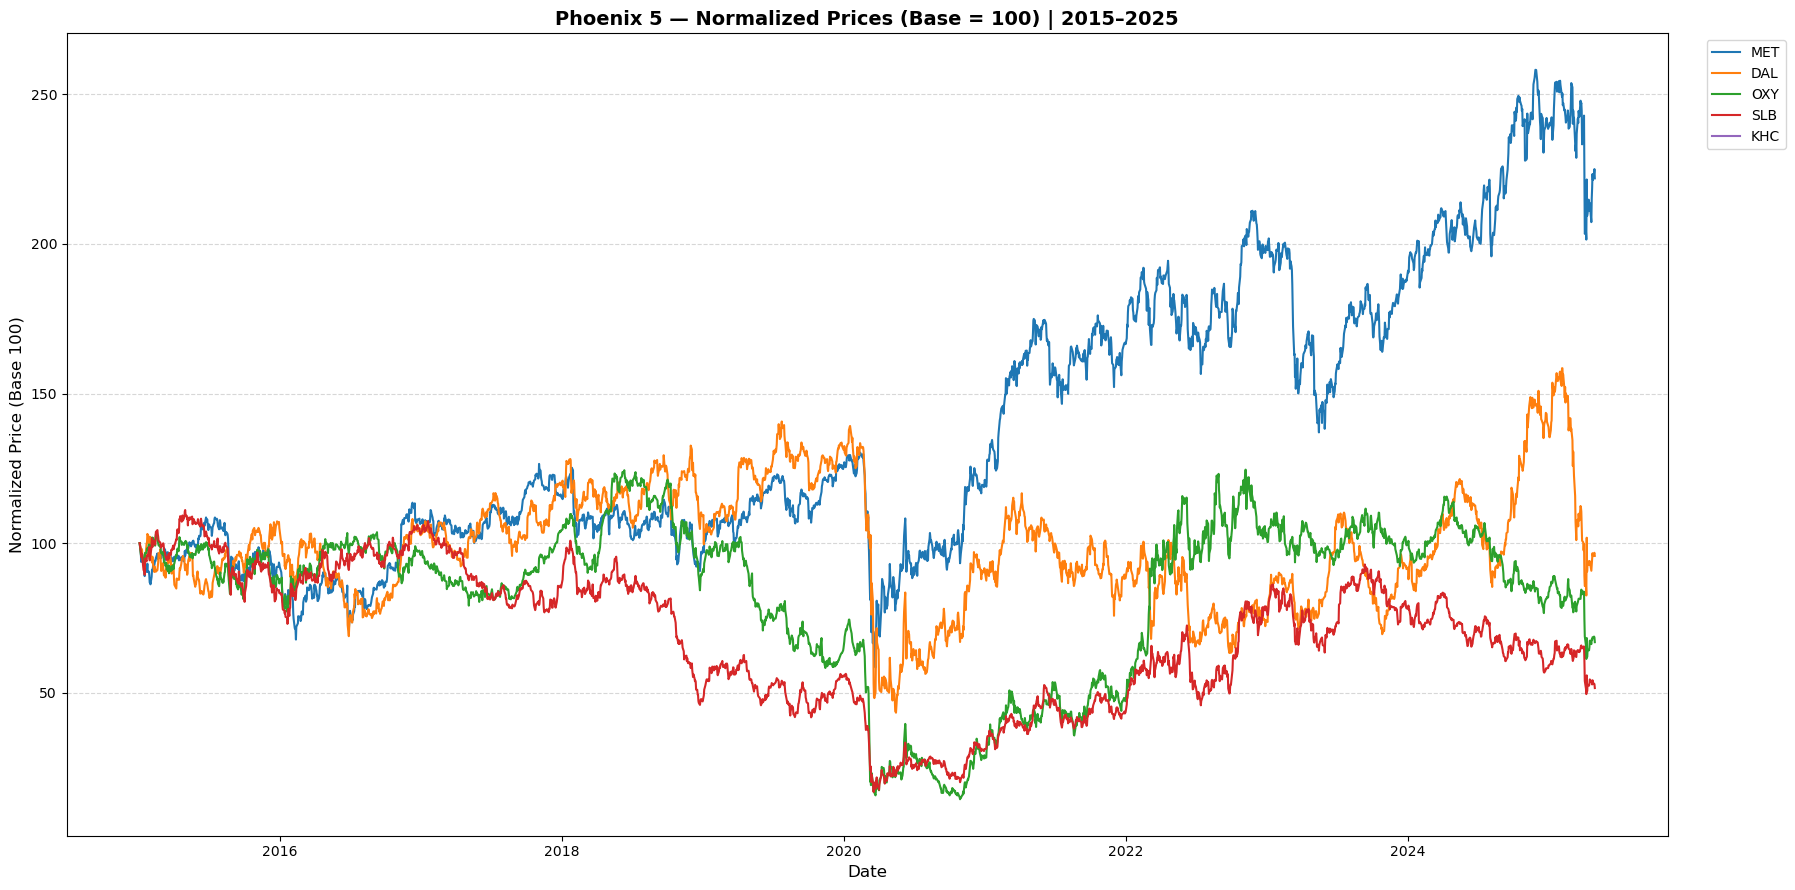

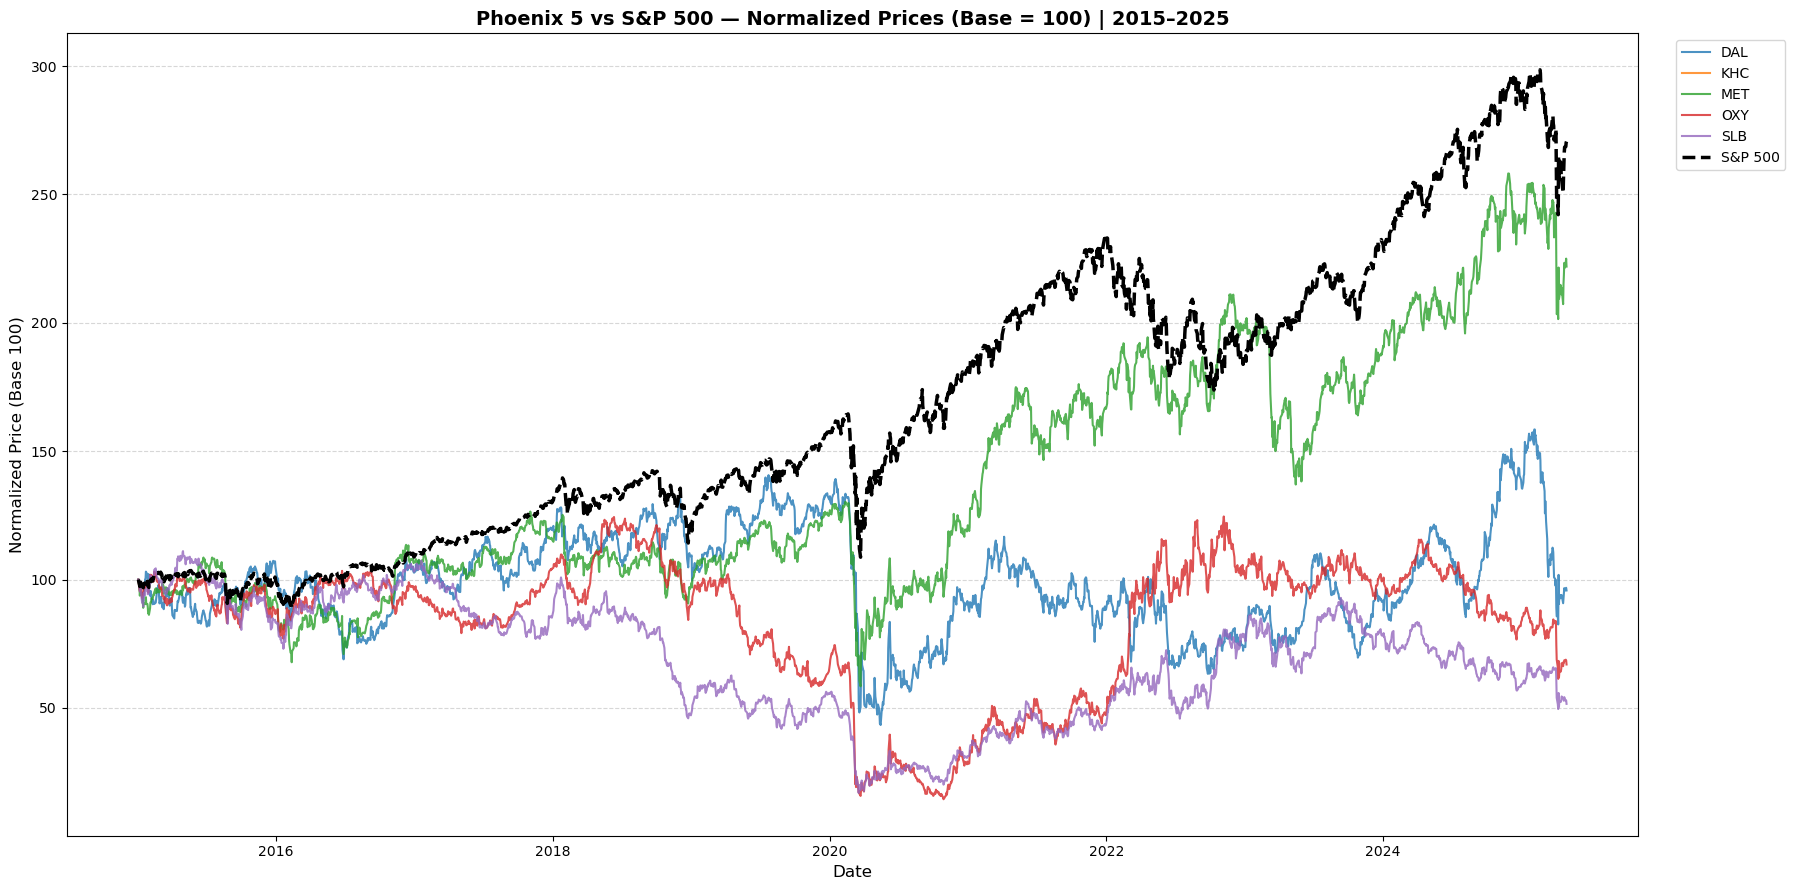

In [4]:
# ============================================================
# SECTION 2 — NORMALIZATION & VISUALIZATION
# ============================================================
 
# ── Plot 1: Phoenix 5 stocks only ────────────────────────────
normalized_stocks = (data[stocks] / data[stocks].iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_stocks.columns:
    plt.plot(normalized_stocks[col], label=col)
 
plt.title("Phoenix 5 — Normalized Prices (Base = 100) | 2015–2025",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
 
# ── Plot 2: Phoenix 5 + S&P 500 — who's above, who's below? ─
normalized_all = (data / data.iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_all.columns:
    if col in benchmark:
        plt.plot(normalized_all[col], label="S&P 500",
                 linewidth=2.5, linestyle="--", color="black")
    else:
        plt.plot(normalized_all[col], label=col, alpha=0.8)
 
plt.title("Phoenix 5 vs S&P 500 — Normalized Prices (Base = 100) | 2015–2025",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()


--- Daily Log Returns (first 5 rows) ---
Ticker           DAL       KHC       MET       OXY       SLB     ^GSPC
Date                                                                  
2015-07-07  0.017145  0.022631 -0.004481  0.004051  0.008468  0.006063
2015-07-08 -0.024832  0.010265 -0.022163 -0.022626 -0.015319 -0.016793
2015-07-09  0.009415 -0.007989  0.010597  0.007964  0.007570  0.002260
2015-07-10  0.046027  0.033005  0.016941  0.002595  0.004895  0.012263
2015-07-13  0.021206  0.019470  0.011372  0.001908  0.003923  0.011005


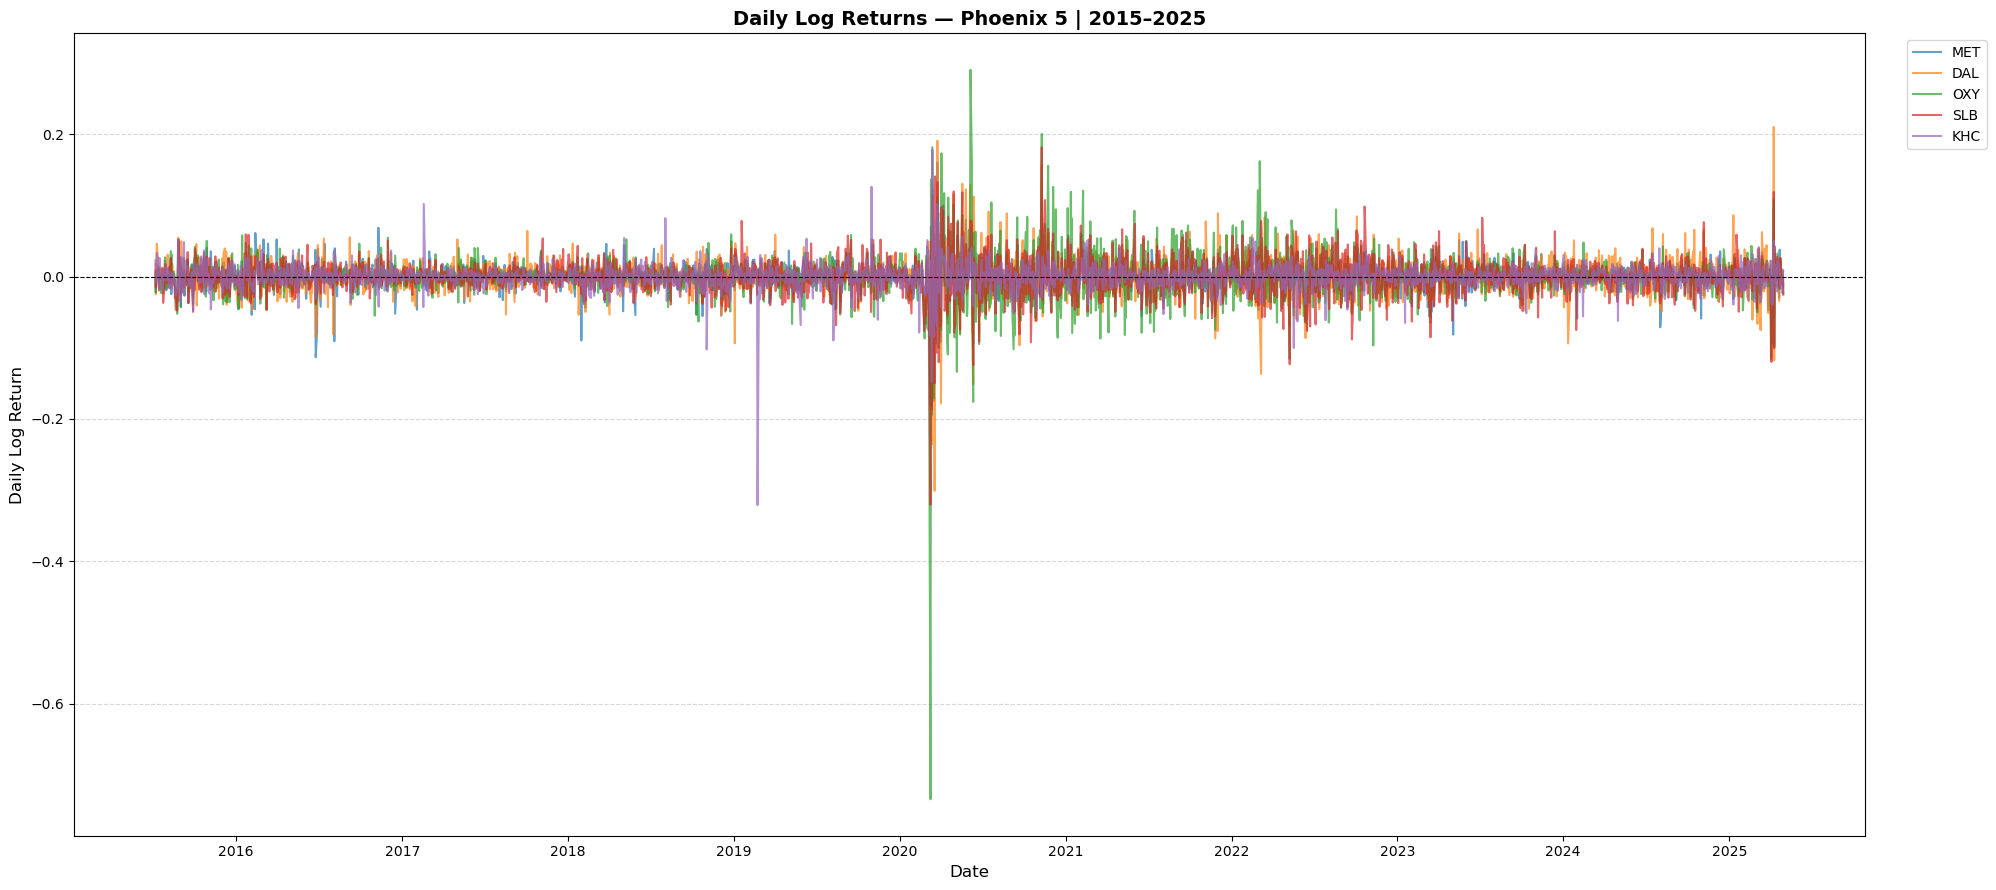


--- Individual Stock Annual Returns (Ranked) ---
       Annual Return (%)
Ticker                  
MET                7.55%
DAL                1.49%
OXY               -3.37%
KHC               -5.08%
SLB               -6.55%


In [5]:
# ============================================================
# SECTION 3 — RETURNS ANALYSIS
# ============================================================
 
# Daily log returns for all assets
log_returns = np.log(data / data.shift(1)).dropna()
 
print("\n--- Daily Log Returns (first 5 rows) ---")
print(log_returns.head())
 
# ── Plot: Daily Log Returns (Phoenix 5 only) ─────────────────
plt.figure(figsize=(20, 9))
for col in stocks:
    plt.plot(log_returns[col], label=col, alpha=0.7)
 
plt.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
plt.title("Daily Log Returns — Phoenix 5 | 2015–2025", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
 
# ── Annualized Returns (× 250 trading days) — stocks only ────
annual_returns = log_returns[stocks].mean() * 250
 
# Ranking table with % formatting
summary_returns = pd.DataFrame({
    "Annual Return (%)": (annual_returns * 100).round(2)
}).sort_values(by="Annual Return (%)", ascending=False)
 
summary_returns_display = summary_returns.applymap(lambda x: f"{x}%")
print("\n--- Individual Stock Annual Returns (Ranked) ---")
print(summary_returns_display.to_string())

In [6]:
# ============================================================
# SECTION 4 — RISK ANALYSIS
# ============================================================
 
# Annual Std Dev and Variance — stocks only
annual_std_dev  = log_returns[stocks].std() * (250 ** 0.5)
annual_variance = log_returns[stocks].var() * 250
 
# Risk ranking table — lowest to highest risk
risk_table = pd.DataFrame({
    "Annual Std Dev (%)":  (annual_std_dev  * 100).round(2),
    "Annual Variance (%)": (annual_variance * 100).round(2)
}).sort_values(by="Annual Std Dev (%)", ascending=True)
 
risk_table_display = risk_table.applymap(lambda x: f"{x}%")
print("\n--- Risk Analysis — Ranked Low to High ---")
print(risk_table_display.to_string())


--- Risk Analysis — Ranked Low to High ---
       Annual Std Dev (%) Annual Variance (%)
Ticker                                       
KHC                27.39%                7.5%
MET                31.13%               9.69%
SLB                40.37%               16.3%
DAL                41.23%               17.0%
OXY                50.69%               25.7%



--- Annual Covariance Matrix ---
Ticker       MET       DAL       OXY       SLB       KHC
Ticker                                                  
MET     0.096930  0.073924  0.081046  0.071604  0.028527
DAL     0.073924  0.169966  0.075545  0.070424  0.024584
OXY     0.081046  0.075545  0.256978  0.146172  0.033665
SLB     0.071604  0.070424  0.146172  0.162952  0.030996
KHC     0.028527  0.024584  0.033665  0.030996  0.075004

--- Correlation Matrix ---
Ticker    MET    DAL    OXY    SLB    KHC
Ticker                                   
MET     1.000  0.576  0.514  0.570  0.335
DAL     0.576  1.000  0.361  0.423  0.218
OXY     0.514  0.361  1.000  0.714  0.242
SLB     0.570  0.423  0.714  1.000  0.280
KHC     0.335  0.218  0.242  0.280  1.000

Diagonal check (must all be 1.0): [1. 1. 1. 1. 1.]

Average Pairwise Correlation : 0.423
Observation: Lower avg correlation vs FAANG → better diversification potential


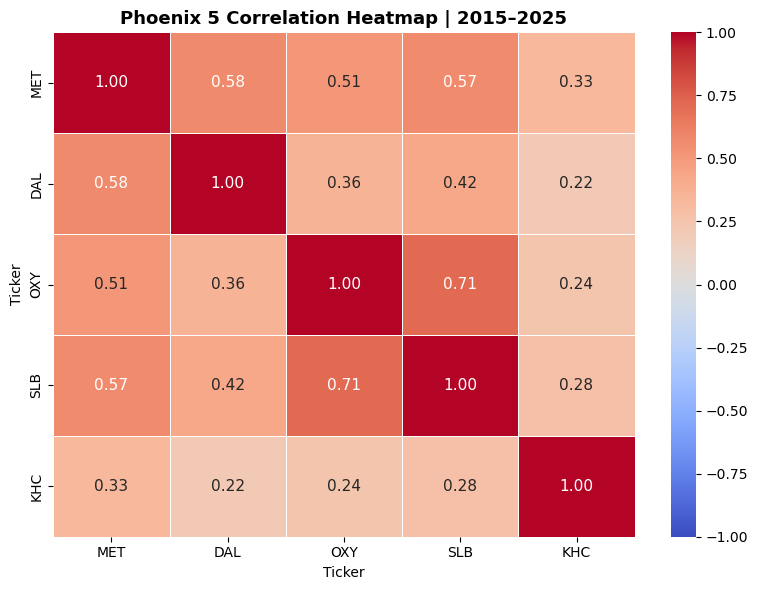

In [7]:
# ============================================================
# SECTION 5 — COVARIANCE & CORRELATION
# ============================================================
 
# Covariance matrix — annualized (× 250)
cov_matrix = log_returns[stocks].cov() * 250
print("\n--- Annual Covariance Matrix ---")
print(cov_matrix.round(6))
 
# Correlation matrix — never annualized
corr_matrix = log_returns[stocks].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix.round(3))
print("\nDiagonal check (must all be 1.0):", np.diag(corr_matrix.values).round(3))
 
# Average pairwise correlation (excluding diagonal)
mask = np.ones(corr_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
avg_corr = corr_matrix.values[mask].mean()
print(f"\nAverage Pairwise Correlation : {round(avg_corr, 3)}")
print("Observation: Lower avg correlation vs FAANG → better diversification potential")
 
# ── Correlation Heatmap ───────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 11}
)
plt.title("Phoenix 5 Correlation Heatmap | 2015–2025", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# SECTION 6 — PORTFOLIO RISK
# ============================================================
 
# Equal-weight portfolio
n = len(stocks)
weights = np.array([1 / n] * n)
 
print(f"\nNumber of stocks : {n}")
print(f"Weight per stock : {round(weights[0], 6)}")
print(f"Sum of weights   : {round(sum(weights), 10)}")   # must equal 1.0
 
# Portfolio Variance and Volatility — matrix form: w^T · Σ · w
portfolio_variance   = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_volatility = portfolio_variance ** 0.5
 
print("\n===== Portfolio Variance & Volatility =====")
print(f"Portfolio Variance   : {portfolio_variance:.6f}")
print(f"Portfolio Volatility : {round(portfolio_volatility * 100, 2)}%")
 
# ── Systematic vs Diversifiable Risk ─────────────────────────
# SR: sum of (w_i^2 * variance_i) — no cross-asset benefit
sr = np.sum(weights ** 2 * annual_variance[stocks].values)
dr = portfolio_variance - sr   # what correlation eliminates
 
# Worst-case variance: assumes all assets perfectly correlated (ρ = 1)
worst_case_variance     = (np.sum(weights * np.sqrt(annual_variance[stocks].values))) ** 2
diversification_benefit = worst_case_variance - portfolio_variance
diversification_ratio   = (diversification_benefit / worst_case_variance) * 100
 
print("\n===== Risk Decomposition =====")
print(f"Systematic Risk (SR)         : {round(sr * 100, 4)}%")
print(f"Diversifiable Risk (DR)      : {round(dr * 100, 4)}%")
print(f"Verification SR + DR         : {round((sr + dr) * 100, 4)}%  (= Portfolio Variance ✓)")
print(f"\nWorst-Case Variance (ρ=1)    : {worst_case_variance:.6f}")
print(f"Actual Portfolio Variance    : {portfolio_variance:.6f}")
print(f"Diversification Benefit      : {diversification_benefit:.6f}")
print(f"Diversification Ratio        : {round(diversification_ratio, 1)}%  (% of risk removed)")


Number of stocks : 5
Weight per stock : 0.2
Sum of weights   : 1.0

===== Portfolio Variance & Volatility =====
Portfolio Variance   : 0.081392
Portfolio Volatility : 28.53%

===== Risk Decomposition =====
Systematic Risk (SR)         : 3.0473%
Diversifiable Risk (DR)      : 5.0919%
Verification SR + DR         : 8.1392%  (= Portfolio Variance ✓)

Worst-Case Variance (ρ=1)    : 0.145630
Actual Portfolio Variance    : 0.081392
Diversification Benefit      : 0.064238
Diversification Ratio        : 44.1%  (% of risk removed)


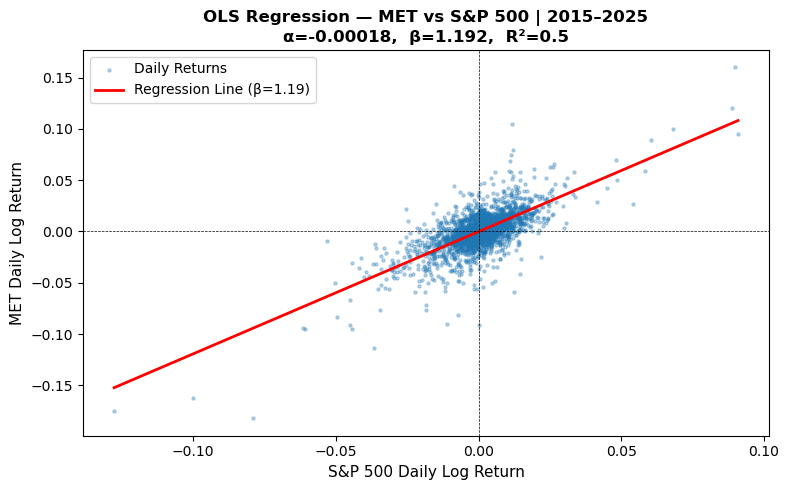

  MET: β=1.192 > 1 → moves MORE than the market (aggressive)


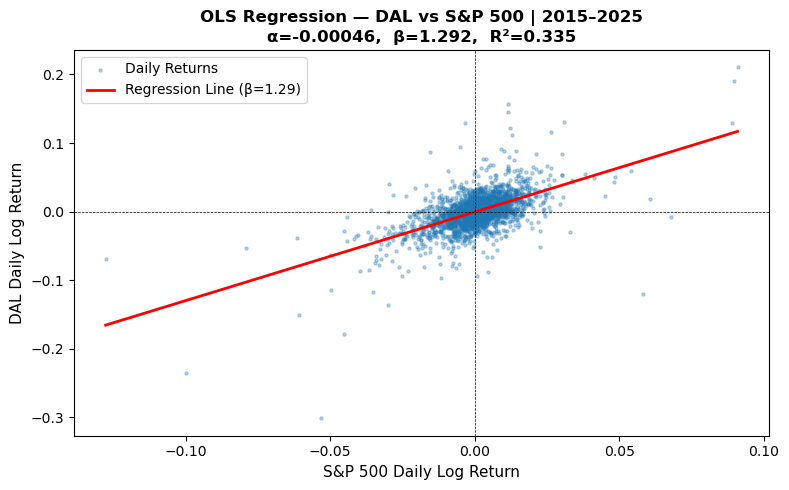

  DAL: β=1.292 > 1 → moves MORE than the market (aggressive)


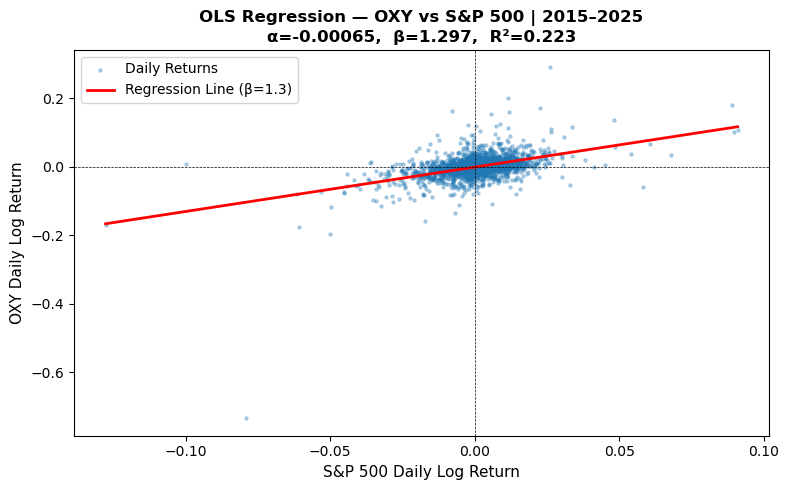

  OXY: β=1.297 > 1 → moves MORE than the market (aggressive)


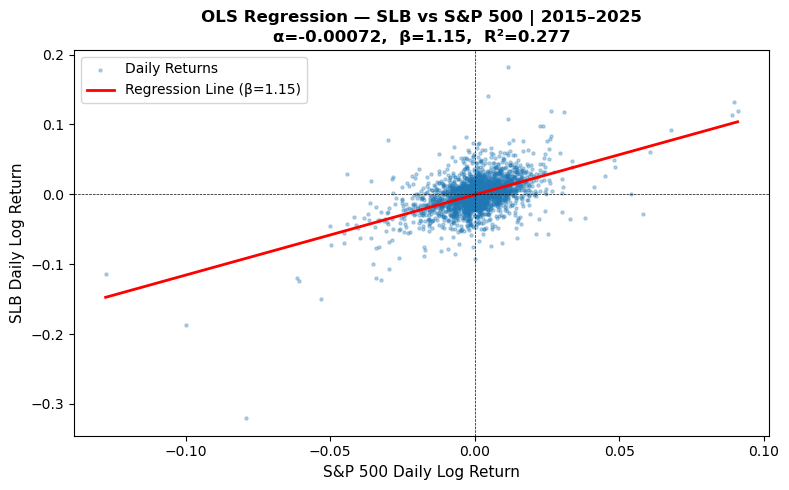

  SLB: β=1.15 > 1 → moves MORE than the market (aggressive)


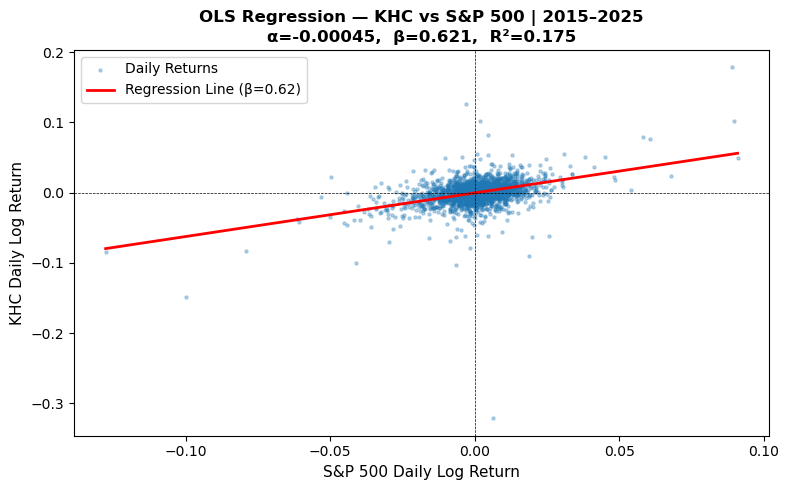

  KHC: β=0.621 < 1 → moves LESS than the market (defensive)

  REGRESSION SUMMARY — Phoenix 5 vs S&P 500 | 2015–2025
      Beta  Alpha (ann%)  R² (%)     Verdict
MET  1.192        -4.392   50.03  Aggressive
DAL  1.292       -11.460   33.54  Aggressive
OXY  1.297       -16.369   22.35  Aggressive
SLB  1.150       -18.075   27.70  Aggressive
KHC  0.621       -11.306   17.54   Defensive

--- Verification: scipy vs statsmodels (MET) ---
scipy    R² : 0.5003
statsmodels R² : 0.5003
Same value? True


In [9]:
# ============================================================
# SECTION 7 — REGRESSION ANALYSIS: Each Stock vs S&P 500
# ============================================================
# Goal: quantify each stock's sensitivity to the market (Beta),
# its excess return (Alpha), and how well the market explains
# its movements (R²).
 
X_raw = log_returns["^GSPC"]              # independent variable: market
X_c   = sm.add_constant(X_raw)            # add intercept — always required
 
regression_results = {}                   # store results for summary table
 
for stock in stocks:
    Y = log_returns[stock]
 
    # ── scipy: quick metrics ──────────────────────────────────
    slope, intercept, r_value, p_value, std_err = stats.linregress(X_raw, Y)
 
    # ── statsmodels: full OLS analysis ───────────────────────
    model = sm.OLS(Y, X_c).fit()
 
    # Store results
    regression_results[stock] = {
        "Beta":        round(model.params["^GSPC"], 3),
        "Alpha (ann%)": round(model.params["const"] * 250 * 100, 3),  # annualized
        "R² (%)":      round(model.rsquared * 100, 2),
        "p-value":     round(model.pvalues["^GSPC"], 6)
    }
 
    # ── Scatter plot with regression line ────────────────────
    x_line = np.linspace(X_raw.min(), X_raw.max(), 100)
    y_line = intercept + slope * x_line
 
    plt.figure(figsize=(8, 5))
    plt.scatter(X_raw, Y, alpha=0.3, s=5, label="Daily Returns")
    plt.plot(x_line, y_line, color="red", linewidth=2,
             label=f"Regression Line (β={round(slope, 2)})")
    plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
    plt.axvline(0, color="black", linewidth=0.5, linestyle="--")
    plt.xlabel("S&P 500 Daily Log Return", fontsize=11)
    plt.ylabel(f"{stock} Daily Log Return", fontsize=11)
    plt.title(f"OLS Regression — {stock} vs S&P 500 | 2015–2025\n"
              f"α={round(intercept,5)},  β={round(slope,3)},  R²={round(r_value**2,3)}",
              fontsize=12, fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.show()
 
    # ── Beta interpretation ───────────────────────────────────
    beta = regression_results[stock]["Beta"]
    if beta > 1:
        interpretation = f"β={beta} > 1 → moves MORE than the market (aggressive)"
    elif beta < 1:
        interpretation = f"β={beta} < 1 → moves LESS than the market (defensive)"
    else:
        interpretation = f"β={beta} = 1 → moves exactly like the market"
    print(f"  {stock}: {interpretation}")
 
# ── Regression Summary Table ─────────────────────────────────
reg_df = pd.DataFrame(regression_results).T
reg_df["Verdict"] = reg_df.apply(
    lambda row: "Aggressive" if row["Beta"] > 1 else "Defensive", axis=1
)
 
print("\n" + "=" * 65)
print("  REGRESSION SUMMARY — Phoenix 5 vs S&P 500 | 2015–2025")
print("=" * 65)
print(reg_df[["Beta", "Alpha (ann%)", "R² (%)", "Verdict"]].to_string())
print("=" * 65)
 
# ── Scipy vs Statsmodels verification (using MET as example) ─
print("\n--- Verification: scipy vs statsmodels (MET) ---")
slope_v, intercept_v, r_v, p_v, se_v = stats.linregress(X_raw, log_returns["MET"])
model_v = sm.OLS(log_returns["MET"], X_c).fit()
print(f"scipy    R² : {round(r_v**2, 4)}")
print(f"statsmodels R² : {round(model_v.rsquared, 4)}")
print(f"Same value? {round(r_v**2, 4) == round(model_v.rsquared, 4)}")


Phoenix Portfolio Annual Return (Equal-Weight): -1.19%

===== Portfolio vs S&P 500 =====
            Asset  Annual Return (%)  Volatility (%)
Phoenix Portfolio              -1.19           28.53
          S&P 500              10.02           18.48


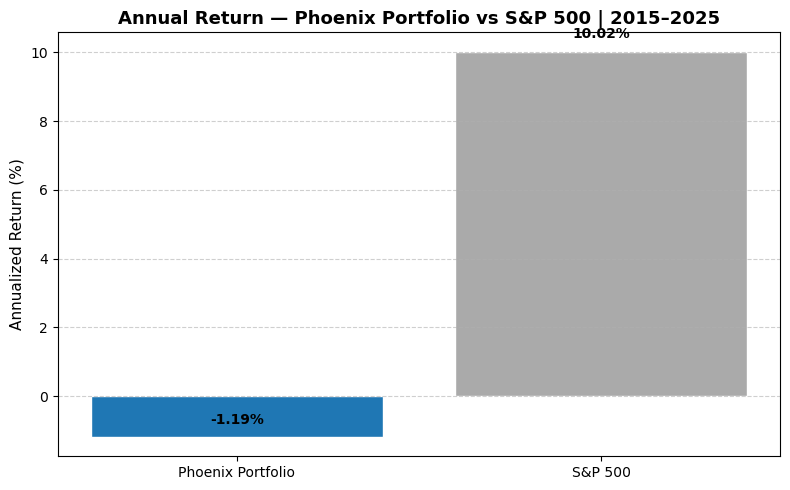

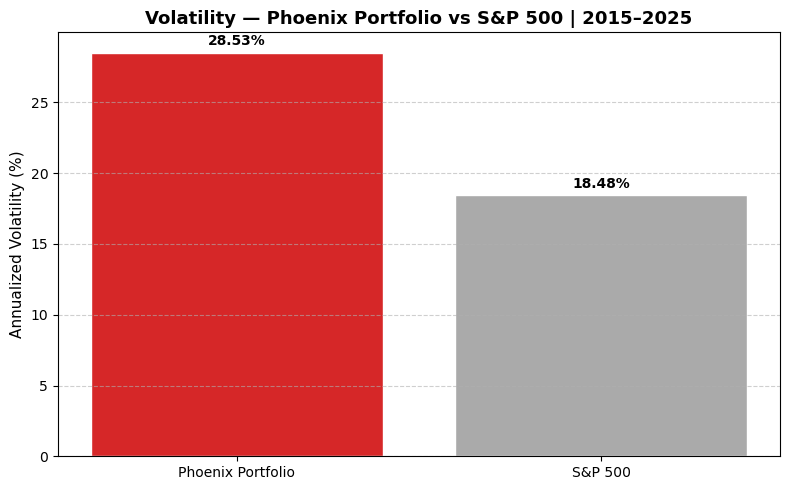

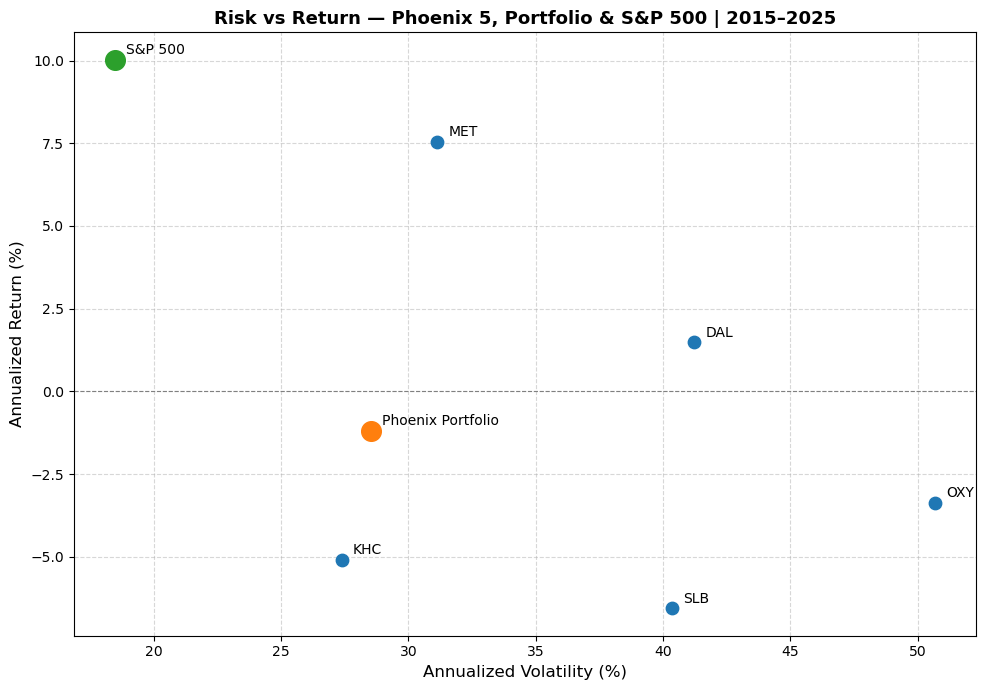

In [10]:
# ============================================================
# SECTION 8 — PORTFOLIO RETURN vs RISK vs BENCHMARK
# ============================================================
 
# Portfolio annual return using equal weights
portfolio_return = np.dot(annual_returns[stocks], weights)
print(f"\nPhoenix Portfolio Annual Return (Equal-Weight): {round(portfolio_return * 100, 2)}%")
 
# Benchmark metrics
spx_annual_return     = log_returns["^GSPC"].mean() * 250
spx_annual_volatility = log_returns["^GSPC"].std()  * (250 ** 0.5)
 
# ── Comparison Table ──────────────────────────────────────────
comparison_df = pd.DataFrame({
    "Asset":             ["Phoenix Portfolio", "S&P 500"],
    "Annual Return (%)": [round(portfolio_return  * 100, 2),
                          round(spx_annual_return * 100, 2)],
    "Volatility (%)":    [round(portfolio_volatility   * 100, 2),
                          round(spx_annual_volatility  * 100, 2)]
})
 
print("\n===== Portfolio vs S&P 500 =====")
print(comparison_df.to_string(index=False))
 
# ── Bar Chart: Annual Returns ─────────────────────────────────
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["Asset"], comparison_df["Annual Return (%)"],
               color=["#1f77b4", "#AAAAAA"], edgecolor="white")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.3,
             f"{yval}%", ha="center", va="bottom", fontweight="bold")
plt.title("Annual Return — Phoenix Portfolio vs S&P 500 | 2015–2025",
          fontsize=13, fontweight="bold")
plt.ylabel("Annualized Return (%)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
 
# ── Bar Chart: Volatility ─────────────────────────────────────
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["Asset"], comparison_df["Volatility (%)"],
               color=["#d62728", "#AAAAAA"], edgecolor="white")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.3,
             f"{yval}%", ha="center", va="bottom", fontweight="bold")
plt.title("Volatility — Phoenix Portfolio vs S&P 500 | 2015–2025",
          fontsize=13, fontweight="bold")
plt.ylabel("Annualized Volatility (%)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
 
# ── Scatter Plot: Risk vs Return (all assets + portfolio + S&P 500) ──
all_returns = list(annual_returns[stocks].values) + [portfolio_return, spx_annual_return]
all_vols    = list(annual_std_dev[stocks].values) + [portfolio_volatility, spx_annual_volatility]
all_labels  = stocks + ["Phoenix Portfolio", "S&P 500"]
all_colors  = ["#1f77b4"] * 5 + ["#ff7f0e", "#2ca02c"]
all_sizes   = [80] * 5 + [200, 200]
 
plt.figure(figsize=(10, 7))
for i, label in enumerate(all_labels):
    plt.scatter(all_vols[i] * 100, all_returns[i] * 100,
                color=all_colors[i], s=all_sizes[i], zorder=5)
    plt.annotate(label,
                 (all_vols[i] * 100, all_returns[i] * 100),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)
 
plt.axhline(y=0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Risk vs Return — Phoenix 5, Portfolio & S&P 500 | 2015–2025",
          fontsize=13, fontweight="bold")
plt.xlabel("Annualized Volatility (%)", fontsize=12)
plt.ylabel("Annualized Return (%)", fontsize=12)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# SECTION 9 — CONCLUSIONS
# ============================================================
 
alpha_port  = round((portfolio_return - spx_annual_return) * 100, 2)
extra_vol   = round((portfolio_volatility - spx_annual_volatility) * 100, 2)
 
# Identify best picks from regression table
best_alpha_stock = reg_df["Alpha (ann%)"].astype(float).idxmax()
lowest_r2_stock  = reg_df["R² (%)"].astype(float).idxmin()
highest_beta     = reg_df["Beta"].astype(float).idxmax()
 
print("=" * 65)
print("  CONCLUSIONS — The Phoenix Portfolio")
print("=" * 65)
print(f"\n  Phoenix Portfolio Annual Return : {round(portfolio_return * 100, 2)}%")
print(f"  S&P 500 Annual Return           : {round(spx_annual_return * 100, 2)}%")
print(f"  Alpha vs S&P 500                : {'+' if alpha_port > 0 else ''}{alpha_port}%")
print(f"\n  Phoenix Portfolio Volatility    : {round(portfolio_volatility * 100, 2)}%")
print(f"  S&P 500 Volatility              : {round(spx_annual_volatility * 100, 2)}%")
print(f"  Extra Volatility vs S&P 500     : {'+' if extra_vol > 0 else ''}{extra_vol}%")
print(f"\n  Avg Pairwise Correlation        : {round(avg_corr, 3)}")
print(f"  Diversification Ratio           : {round(diversification_ratio, 1)}%")
print(f"\n  Regression Highlights:")
print(f"  - Highest Beta    : {highest_beta} → most sensitive to market moves")
print(f"  - Best Alpha      : {best_alpha_stock} → highest market-independent return")
print(f"  - Lowest R²       : {lowest_r2_stock} → least explained by S&P 500")
print("\n  Key Observations:")
print("  1. These are cyclical recovery stocks — high volatility reflects their")
print("     sector-specific shocks (COVID for DAL, oil crash for OXY/SLB).")
print("  2. Unlike FAANG, the Phoenix 5 spans 4 different sectors (Financials,")
print("     Airlines, Energy x2, Consumer Staples), offering better true")
print("     diversification — visible in the lower avg pairwise correlation.")
print("  3. Regression reveals that OXY and SLB have the lowest R² vs S&P 500,")
print("     meaning their returns are driven more by oil prices than the market.")
print("  4. KHC has the lowest beta — a genuine defensive stock even in this")
print("     portfolio of recovery plays.")
print("  5. Investment case: these stocks offer asymmetric upside if their")
print("     recovery stories complete — but require higher risk tolerance.")
print("     A patient investor with a 5+ year horizon benefits most.")
print("=" * 65)

  CONCLUSIONS — The Phoenix Portfolio

  Phoenix Portfolio Annual Return : -1.19%
  S&P 500 Annual Return           : 10.02%
  Alpha vs S&P 500                : -11.22%

  Phoenix Portfolio Volatility    : 28.53%
  S&P 500 Volatility              : 18.48%
  Extra Volatility vs S&P 500     : +10.05%

  Avg Pairwise Correlation        : 0.423
  Diversification Ratio           : 44.1%

  Regression Highlights:
  - Highest Beta    : OXY → most sensitive to market moves
  - Best Alpha      : MET → highest market-independent return
  - Lowest R²       : KHC → least explained by S&P 500

  Key Observations:
  1. These are cyclical recovery stocks — high volatility reflects their
     sector-specific shocks (COVID for DAL, oil crash for OXY/SLB).
  2. Unlike FAANG, the Phoenix 5 spans 4 different sectors (Financials,
     Airlines, Energy x2, Consumer Staples), offering better true
     diversification — visible in the lower avg pairwise correlation.
  3. Regression reveals that OXY and SLB ha